<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CUDA_Accelerated_SVG_PNG_to_Layout_PEC_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# -*- coding: utf-8 -*-
"""CUDA-Accelerated Layout Generation: DUV Immersion vs E-beam PEC.

This script performs Optical Proximity Correction (OPC) for 193nm Immersion
DUV lithography and E-beam Proximity Effect Correction (PEC). It compares
the two patterning modalities using CUDA acceleration.

Usage:
    Run in a Google Colab environment with a GPU runtime.
    Upload an SVG or PNG file when prompted.
"""

!nvidia-smi

Tue Jan 13 01:30:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   75C    P0             35W /   72W |     309MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

CuPy is already installed.


Saving googlelogo_clr_74x24px.svg to googlelogo_clr_74x24px (6).svg
Pixel Size: 3.91 nm
Running DUV Immersion OPC (Airy Model)...
Running E-beam PEC...
Running E-beam Monte Carlo Simulation...
Running E-beam PEC...
Running E-beam Monte Carlo Simulation...


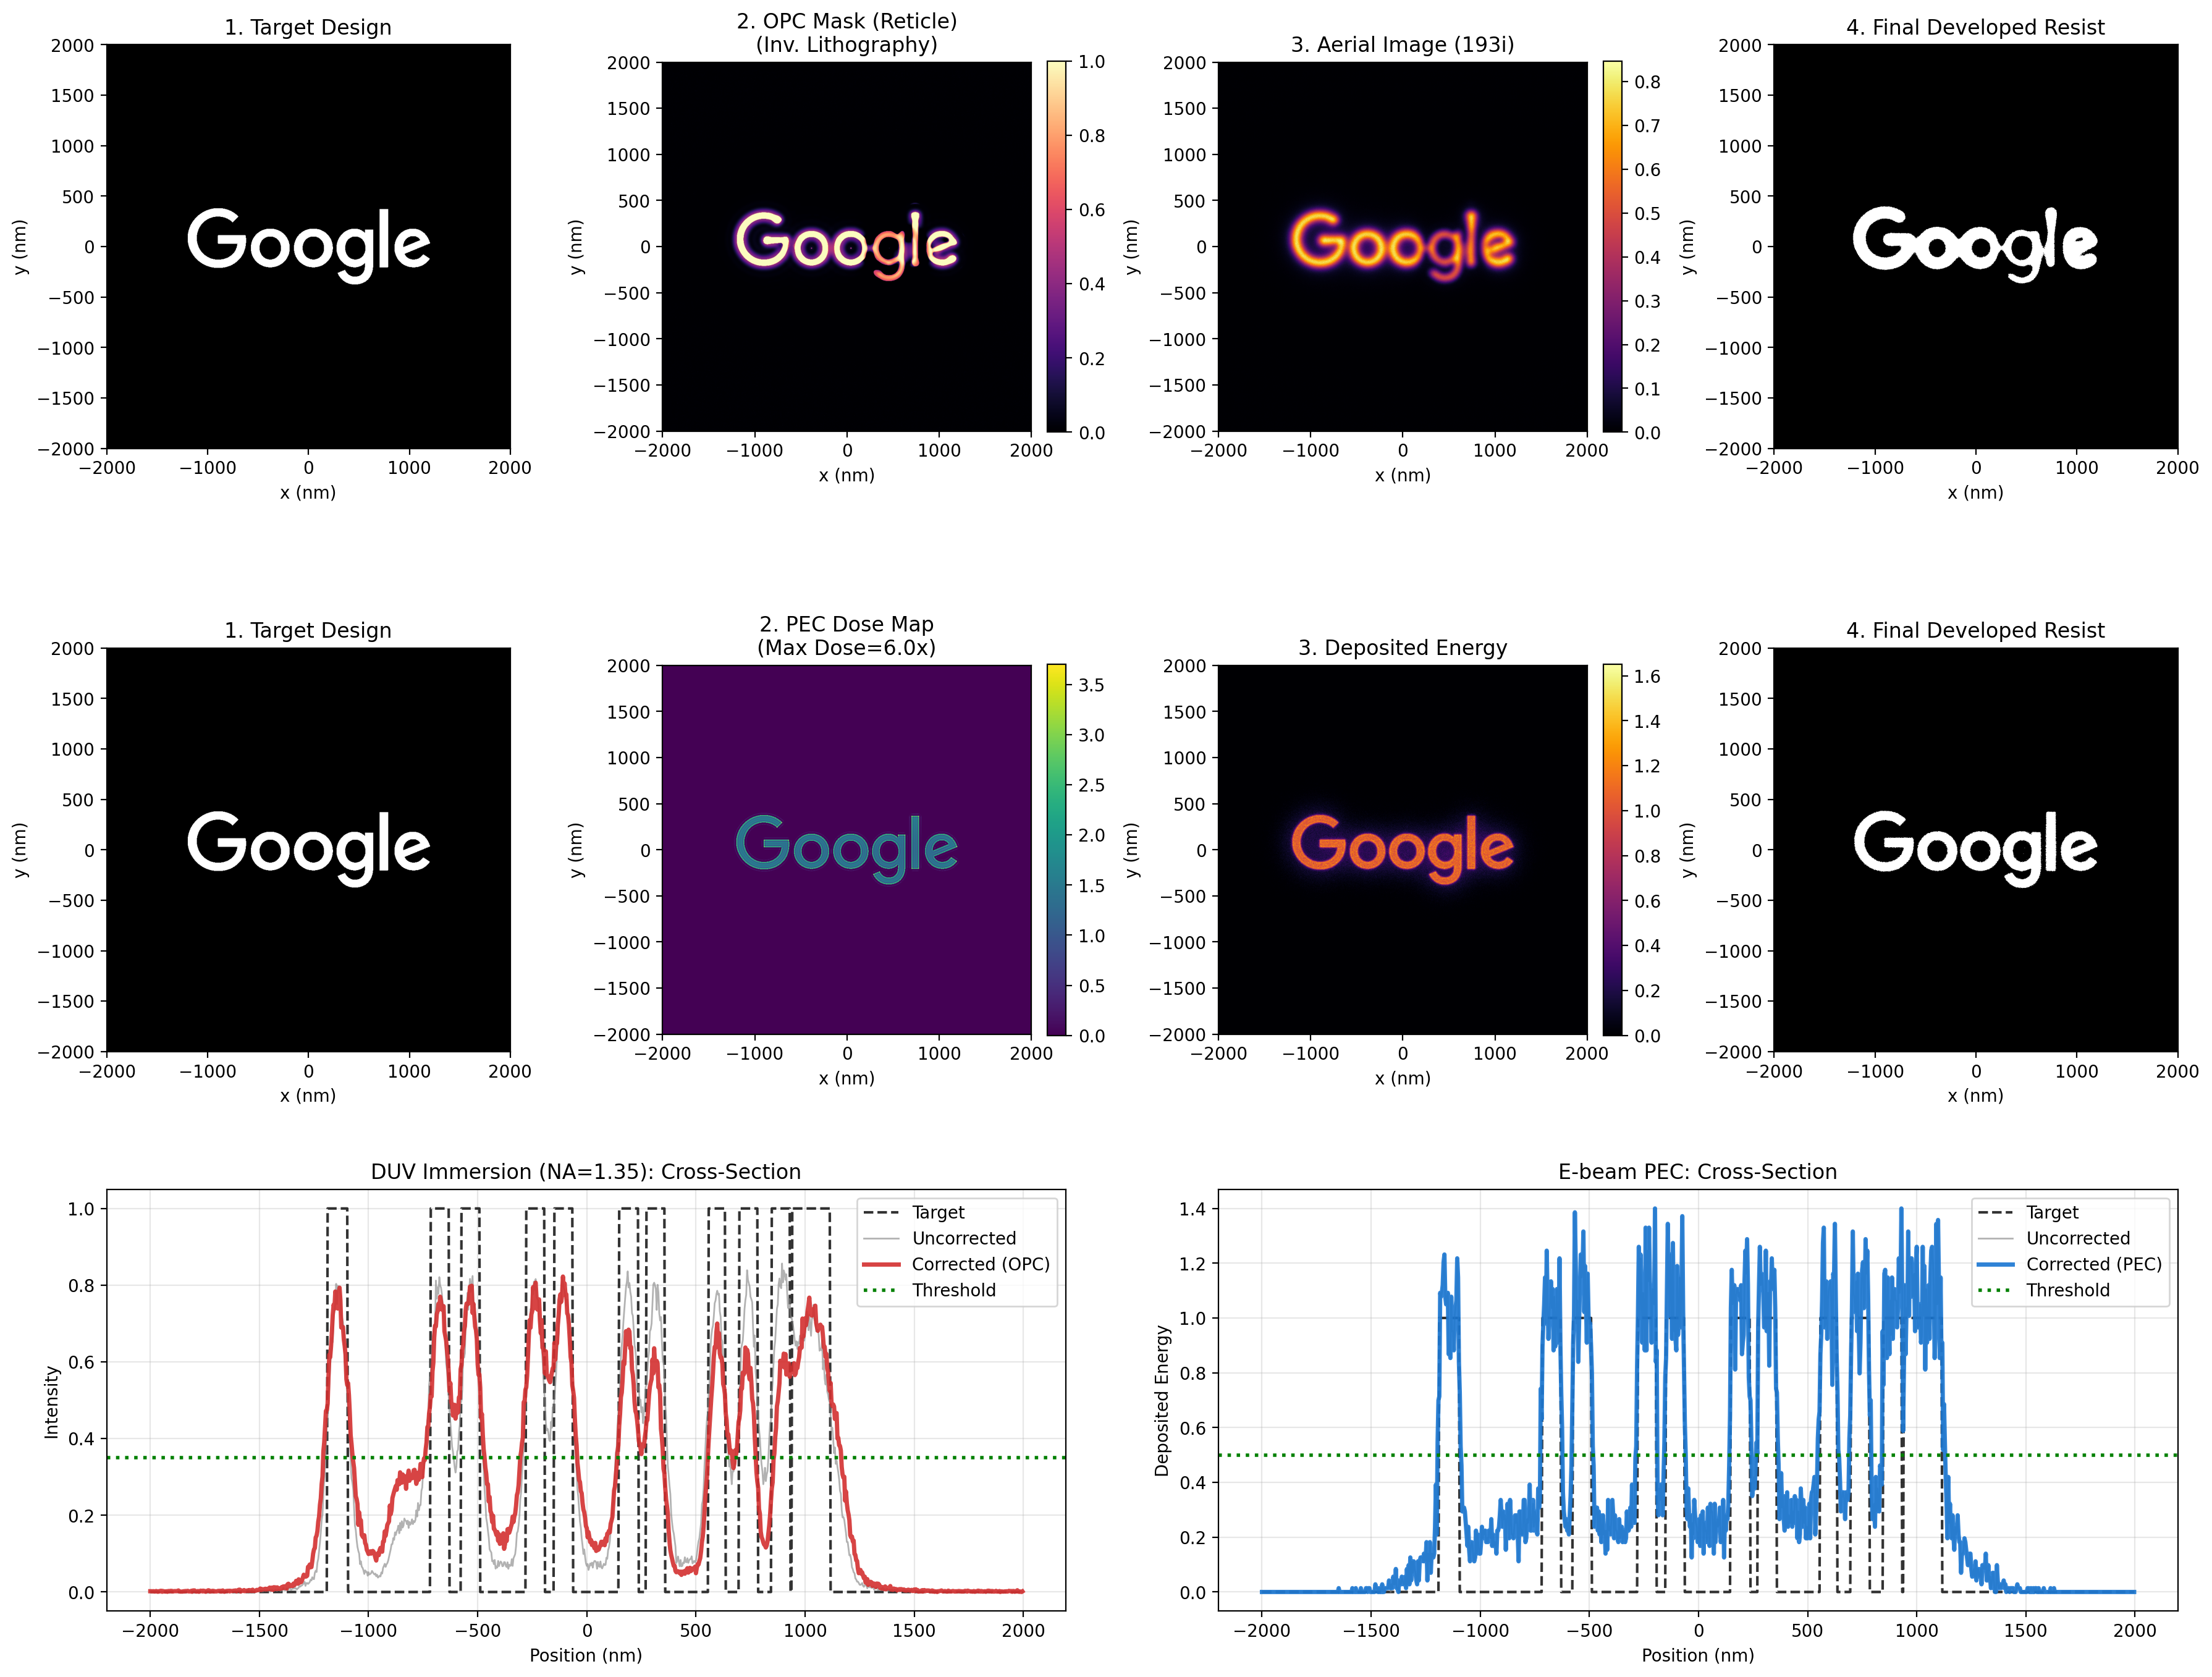

In [ ]:
import io
import os
import re
import sys
import subprocess
from dataclasses import dataclass
from typing import Tuple, Dict

# --- Environment Setup (Colab Specifics) ---
def _install_dependencies() -> None:
    """Check for CUDA and install necessary system/Python libraries."""
    try:
        import cupy  # noqa: F401
        print("CuPy is already installed.")
    except ImportError:
        print("Detecting CUDA version and installing dependencies...")
        # Detect CUDA version
        cuda_major = 12  # Default
        try:
            out = subprocess.check_output(["nvidia-smi"], text=True)
            match = re.search(r"CUDA Version:\s+(\d+)\.", out)
            if match:
                cuda_major = int(match.group(1))
        except Exception:
            pass

        cupy_pkg = f"cupy-cuda{cuda_major}x"
        print(f"Installing {cupy_pkg}, cairosvg, and pillow...")

        # Install system libs for Cairo (SVG rendering)
        subprocess.check_call(["bash", "-lc", "apt-get -y update -qq"])
        subprocess.check_call([
            "bash", "-lc",
            "apt-get -y install -qq libcairo2 libpango-1.0-0 libpangocairo-1.0-0"
        ])

        # Install Python packages
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", cupy_pkg])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pillow", "cairosvg"])
        print("Installation complete.")

_install_dependencies()

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
import cupy as cp
import cupyx.scipy.special as cpx_special  # For Bessel functions (J1)
import cairosvg
from google.colab import files

# --- Configuration & Control Knobs ---

# Set Matplotlib DPI as requested
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "image.cmap": "inferno",
})

@dataclass(frozen=True)
class SimConfig:
    """Simulation configuration parameters (Control Knobs)."""

    # --- Domain Setup ---
    domain_width_um: float = 4.0          # Reduced width for higher res inspection
    grid_n: int = 1024                    # Increased grid for DUV fringes
    shape_fill_fraction: float = 0.60     # Target fill size relative to canvas

    # --- Input Processing ---
    alpha_threshold: float = 0.15         # Cutoff for input transparency
    binarize_target: bool = True          # Force hard binary target mask

    # --- DUV Immersion Optical Model ---
    # 193i (ArF Immersion) parameters
    opt_wavelength_nm: float = 193.0      # Source wavelength
    opt_na: float = 1.35                  # Numerical Aperture (Water Immersion)
    opt_refractive_index: float = 1.44    # Refractive index of water
    opt_k1_factor: float = 0.30           # Process capability factor

    opt_threshold: float = 0.35           # Lower threshold common for high-contrast resist
    opt_photons_per_pixel: float = 2000.0 # Higher dose for DUV

    # OPC Optimization Parameters
    opt_opc_iters: int = 100              # Gradient descent iterations
    opt_opc_step: float = 0.80            # Gradient descent step size
    opt_sigmoid_slope: float = 0.05       # Steepness of sigmoid for optimization

    # --- E-beam Lithography (PEC) ---
    eb_sigma_f_nm: float = 8.0            # Forward scattering (sharp beam)
    eb_sigma_b_nm: float = 140.0          # Backscattering sigma
    eb_eta: float = 0.40                  # Backscattering ratio
    eb_threshold: float = 0.50            # Resist clearing threshold

    # PEC Optimization Parameters
    eb_reg_lambda: float = 5.0e-3         # Tikhonov regularization factor
    eb_dose_clip: float = 6.0             # Max allowed dose multiplier

    # --- Monte Carlo & System ---
    mc_electrons_total: int = 4_000_000   # Total electrons for simulation
    mc_chunk_size: int = 500_000          # Batch size for GPU
    seed: int = 42                        # Random seed


CFG = SimConfig()

# --- Utility Functions ---

def domain_width_nm(cfg: SimConfig) -> float:
    """Convert domain width to nanometers."""
    return float(cfg.domain_width_um) * 1000.0

def pixel_nm(cfg: SimConfig) -> float:
    """Calculate pixel size in nanometers."""
    return domain_width_nm(cfg) / float(cfg.grid_n)

def airy_disk_psf(shape: Tuple[int, int], cfg: SimConfig, px_size_nm: float) -> cp.ndarray:
    """
    Generate an Airy Disk PSF for diffraction-limited DUV lithography.
    PSF(r) ~ [2*J1(v)/v]^2, where v = k0 * NA * r
    """
    ny, nx = shape
    y = cp.arange(ny) - ny // 2
    x = cp.arange(nx) - nx // 2
    yy, xx = cp.meshgrid(y, x, indexing="ij")

    # Radial distance in nanometers
    r_nm = cp.sqrt(xx**2 + yy**2) * px_size_nm

    # Optical coordinate v
    # v = (2 * pi / lambda) * NA * r
    k0 = 2.0 * np.pi / cfg.opt_wavelength_nm
    v = k0 * cfg.opt_na * r_nm

    # Jinc function: 2 * J1(v) / v
    # Handle v=0 singularity
    epsilon = 1e-8
    v = cp.maximum(v, epsilon)
    jinc = 2.0 * cpx_special.j1(v) / v

    # Intensity Point Spread Function is |Amplitude|^2
    psf = jinc ** 2

    # Normalize to sum = 1
    return (psf / cp.sum(psf)).astype(cp.float32)

def gaussian_psf(shape: Tuple[int, int], sigma_px: float) -> cp.ndarray:
    """Generate a centered 2D Gaussian Point Spread Function."""
    ny, nx = shape
    y = cp.arange(ny) - ny // 2
    x = cp.arange(nx) - nx // 2
    yy, xx = cp.meshgrid(y, x, indexing="ij")
    psf = cp.exp(-(xx**2 + yy**2) / (2.0 * float(sigma_px)**2))
    return (psf / cp.sum(psf)).astype(cp.float32)

def double_gaussian_psf(
    shape: Tuple[int, int],
    sigma_f_px: float,
    sigma_b_px: float,
    eta: float
) -> cp.ndarray:
    """Generate a mixture of two Gaussians (Point Spread Function)."""
    psf_f = gaussian_psf(shape, sigma_f_px)
    psf_b = gaussian_psf(shape, sigma_b_px)
    psf = (1.0 - float(eta)) * psf_f + float(eta) * psf_b
    return (psf / cp.sum(psf)).astype(cp.float32)

def fft_convolve2d(img: cp.ndarray, psf_f: cp.ndarray) -> cp.ndarray:
    """Perform 2D convolution via FFT."""
    out = cp.fft.ifft2(cp.fft.fft2(img) * psf_f)
    return cp.real(out).astype(cp.float32)

# --- Input Handling ---

def load_and_process_image(cfg: SimConfig) -> Tuple[cp.ndarray, cp.ndarray]:
    """Prompt user to upload an image and process it."""
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No file uploaded.")

    filename = next(iter(uploaded.keys()))
    ext = os.path.splitext(filename)[1].lower().strip()

    if ext == ".svg":
        with open(filename, "rb") as f:
            svg_bytes = f.read()
        png_bytes = cairosvg.svg2png(bytestring=svg_bytes, output_width=2048)
        img = Image.open(io.BytesIO(png_bytes)).convert("RGBA")
    else:
        img = Image.open(filename).convert("RGBA")

    arr = np.asarray(img)
    alpha = arr[:, :, 3].astype(np.float32) / 255.0

    ys, xs = np.where(alpha > cfg.alpha_threshold)
    if len(ys) == 0:
        raise ValueError("Image is fully transparent.")

    alpha_crop = alpha[ys.min():ys.max()+1, xs.min():xs.max()+1]

    max_dim = int(cfg.grid_n * cfg.shape_fill_fraction)
    pil_crop = Image.fromarray((alpha_crop * 255).astype(np.uint8))

    w, h = pil_crop.size
    scale = min(max_dim / w, max_dim / h)
    new_size = (int(w * scale), int(h * scale))
    pil_resized = pil_crop.resize(new_size, Image.Resampling.LANCZOS)

    target_cpu = np.zeros((cfg.grid_n, cfg.grid_n), dtype=np.float32)
    mask = np.array(pil_resized).astype(np.float32) / 255.0

    y_off = (cfg.grid_n - new_size[1]) // 2
    x_off = (cfg.grid_n - new_size[0]) // 2
    target_cpu[y_off:y_off+new_size[1], x_off:x_off+new_size[0]] = mask

    if cfg.binarize_target:
        target_cpu = (target_cpu > cfg.alpha_threshold).astype(np.float32)

    return cp.asarray(target_cpu)

# --- Simulation Logic ---

def run_optical_correction(
    target: cp.ndarray,
    cfg: SimConfig,
    psf_f: cp.ndarray
) -> Tuple[cp.ndarray, cp.ndarray]:
    """Perform OPC for DUV Immersion."""
    print("Running DUV Immersion OPC (Airy Model)...")

    mask = target.copy()
    rng = cp.random.default_rng(cfg.seed)
    mask += 0.01 * rng.standard_normal(mask.shape, dtype=cp.float32)
    mask = cp.clip(mask, 0.0, 1.0)

    for _ in range(cfg.opt_opc_iters):
        aerial = fft_convolve2d(mask, psf_f)
        diff = (aerial - cfg.opt_threshold) / cfg.opt_sigmoid_slope
        printed_soft = 1.0 / (1.0 + cp.exp(-diff))

        error = printed_soft - target
        grad = error * (printed_soft * (1.0 - printed_soft)) / cfg.opt_sigmoid_slope
        grad_mask = fft_convolve2d(grad, psf_f)

        mask = cp.clip(mask - cfg.opt_opc_step * grad_mask, 0.0, 1.0)

    # Final Verification (Monte Carlo Photon Shot Noise)
    expected = fft_convolve2d(mask, psf_f)
    lam = cp.clip(expected * cfg.opt_photons_per_pixel, 0.0, None)
    noisy = rng.poisson(lam).astype(cp.float32) / cfg.opt_photons_per_pixel

    return mask, noisy

def run_ebeam_correction(
    target: cp.ndarray,
    cfg: SimConfig,
    psf_f: cp.ndarray,
    sigma_f_px: float,
    sigma_b_px: float
) -> Tuple[cp.ndarray, cp.ndarray]:
    """Perform PEC using Deconvolution."""
    print("Running E-beam PEC...")

    target_f = cp.fft.fft2(target)
    denom = (cp.abs(psf_f)**2) + cfg.eb_reg_lambda
    dose_f = target_f * cp.conj(psf_f) / denom

    dose = cp.real(cp.fft.ifft2(dose_f))
    dose = cp.clip(dose, 0.0, cfg.eb_dose_clip)

    print("Running E-beam Monte Carlo Simulation...")
    dose_flat = dose.ravel()
    dose_sum = float(cp.sum(dose_flat))

    if dose_sum == 0:
        return dose, cp.zeros_like(dose)

    cdf = cp.cumsum(dose_flat)
    cdf_max = cdf[-1]

    rng = cp.random.default_rng(cfg.seed)
    energy_acc = cp.zeros(dose.size, dtype=cp.int32)

    n_processed = 0
    while n_processed < cfg.mc_electrons_total:
        batch = min(cfg.mc_chunk_size, cfg.mc_electrons_total - n_processed)

        u = rng.random(batch, dtype=cp.float32) * cdf_max
        indices = cp.searchsorted(cdf, u).astype(cp.int32)

        y0 = indices // cfg.grid_n
        x0 = indices % cfg.grid_n

        is_backscatter = rng.random(batch) < cfg.eb_eta
        sigmas = cp.where(is_backscatter, sigma_b_px, sigma_f_px)

        dy = rng.standard_normal(batch) * sigmas
        dx = rng.standard_normal(batch) * sigmas

        y_final = cp.clip(y0 + cp.rint(dy).astype(cp.int32), 0, cfg.grid_n - 1)
        x_final = cp.clip(x0 + cp.rint(dx).astype(cp.int32), 0, cfg.grid_n - 1)

        flat_indices = y_final * cfg.grid_n + x_final
        cp.add.at(energy_acc, flat_indices, 1)
        n_processed += batch

    energy_mc = energy_acc.astype(cp.float32) / cfg.mc_electrons_total * dose_sum
    energy_mc = energy_mc.reshape((cfg.grid_n, cfg.grid_n))

    return dose, energy_mc

# --- Main Execution ---

target_gpu = load_and_process_image(CFG)
px_size = pixel_nm(CFG)
print(f"Pixel Size: {px_size:.2f} nm")

# 1. DUV Immersion PSF (Airy Disk)
psf_opt = airy_disk_psf((CFG.grid_n, CFG.grid_n), CFG, px_size)
psf_opt_f = cp.fft.fft2(cp.fft.ifftshift(psf_opt))

# 2. E-beam PSF (Double Gaussian)
psf_eb = double_gaussian_psf(
    (CFG.grid_n, CFG.grid_n),
    CFG.eb_sigma_f_nm / px_size,
    CFG.eb_sigma_b_nm / px_size,
    CFG.eb_eta
)
psf_eb_f = cp.fft.fft2(cp.fft.ifftshift(psf_eb))

# 3. Run Corrected Simulations
# Optical (Corrected)
opc_mask, opc_result = run_optical_correction(target_gpu, CFG, psf_opt_f)
# Optical (Uncorrected Baseline)
opt_unc_aerial = fft_convolve2d(target_gpu, psf_opt_f)
rng = cp.random.default_rng(CFG.seed)
lam_unc = cp.clip(opt_unc_aerial * CFG.opt_photons_per_pixel, 0.0, None)
opt_unc_result = rng.poisson(lam_unc).astype(cp.float32) / CFG.opt_photons_per_pixel

# E-beam (Corrected)
pec_dose, pec_result = run_ebeam_correction(
    target_gpu, CFG, psf_eb_f,
    CFG.eb_sigma_f_nm / px_size, CFG.eb_sigma_b_nm / px_size
)
# E-beam (Uncorrected Baseline)
eb_unc_dose = target_gpu.copy()
_, eb_unc_result = run_ebeam_correction(
    eb_unc_dose, CFG, psf_eb_f,
    CFG.eb_sigma_f_nm / px_size, CFG.eb_sigma_b_nm / px_size
)

# --- Visualization ---

def plot_comprehensive_results(
    target: cp.ndarray,
    opc_mask: cp.ndarray,
    opt_corr: cp.ndarray,
    opt_unc: cp.ndarray,
    pec_dose: cp.ndarray,
    eb_corr: cp.ndarray,
    eb_unc: cp.ndarray,
    cfg: SimConfig
) -> None:
    """Visualize 2D Mask/Dose maps and 1D Line Cuts with Nanometer axes."""

    # 1. Transfer to CPU
    c_target = cp.asnumpy(target)
    c_opc_mask = cp.asnumpy(opc_mask)
    c_opt_corr = cp.asnumpy(opt_corr)
    c_opt_unc = cp.asnumpy(opt_unc)
    c_pec_dose = cp.asnumpy(pec_dose)
    c_eb_corr = cp.asnumpy(eb_corr)
    c_eb_unc = cp.asnumpy(eb_unc)

    # Generate Binary "Developed" Images
    c_opt_dev = (c_opt_corr >= cfg.opt_threshold).astype(np.float32)
    c_eb_dev = (c_eb_corr >= cfg.eb_threshold).astype(np.float32)

    # 2. Setup Plot Grid
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.8])

    # Calculate Extent in Nanometers
    # domain_width_nm is defined in the utility functions earlier
    width_nm = domain_width_nm(cfg)
    extent = [-width_nm/2, width_nm/2, -width_nm/2, width_nm/2]

    # --- Row 1: DUV Immersion Lithography ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(c_target, extent=extent, cmap='gray')
    ax1.set_title("1. Target Design")

    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(c_opc_mask, extent=extent, cmap='magma')
    ax2.set_title(f"2. OPC Mask (Reticle)\n(Inv. Lithography)")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.imshow(c_opt_corr, extent=extent, cmap='inferno')
    ax3.set_title("3. Aerial Image (193i)")
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    ax4 = fig.add_subplot(gs[0, 3])
    ax4.imshow(c_opt_dev, extent=extent, cmap='gray')
    ax4.set_title("4. Final Developed Resist")

    # --- Row 2: E-beam Lithography ---
    ax5 = fig.add_subplot(gs[1, 0])
    ax5.imshow(c_target, extent=extent, cmap='gray')
    ax5.set_title("1. Target Design")

    ax6 = fig.add_subplot(gs[1, 1])
    im6 = ax6.imshow(c_pec_dose, extent=extent, cmap='viridis')
    ax6.set_title(f"2. PEC Dose Map\n(Max Dose={cfg.eb_dose_clip}x)")
    plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04)

    ax7 = fig.add_subplot(gs[1, 2])
    im7 = ax7.imshow(c_eb_corr, extent=extent, cmap='inferno')
    ax7.set_title("3. Deposited Energy")
    plt.colorbar(im7, ax=ax7, fraction=0.046, pad=0.04)

    ax8 = fig.add_subplot(gs[1, 3])
    ax8.imshow(c_eb_dev, extent=extent, cmap='gray')
    ax8.set_title("4. Final Developed Resist")

    # Apply nm labels to all 2D plots
    for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]:
        ax.set_xlabel("x (nm)")
        ax.set_ylabel("y (nm)")

    # --- Row 3: 1D Cross-Section Analysis ---
    mid = cfg.grid_n // 2
    # Calculate x-axis in Nanometers directly
    x_axis_nm = (np.arange(cfg.grid_n) - mid) * pixel_nm(cfg)

    # Optical Cut
    ax9 = fig.add_subplot(gs[2, :2])
    ax9.set_title(f"DUV Immersion (NA={cfg.opt_na}): Cross-Section")
    ax9.plot(x_axis_nm, c_target[mid, :], 'k--', linewidth=1.5, alpha=0.8, label="Target")
    ax9.plot(x_axis_nm, c_opt_unc[mid, :], color='gray', linewidth=1, alpha=0.6, label="Uncorrected")
    ax9.plot(x_axis_nm, c_opt_corr[mid, :], color='#D32F2F', linewidth=2.5, alpha=0.9, label="Corrected (OPC)")
    ax9.axhline(cfg.opt_threshold, color='green', linestyle=':', linewidth=2, label="Threshold")
    ax9.set_xlabel("Position (nm)")
    ax9.set_ylabel("Intensity")
    ax9.legend(loc='upper right')
    ax9.grid(True, alpha=0.3)

    # E-beam Cut
    ax10 = fig.add_subplot(gs[2, 2:])
    ax10.set_title("E-beam PEC: Cross-Section")
    ax10.plot(x_axis_nm, c_target[mid, :], 'k--', linewidth=1.5, alpha=0.8, label="Target")
    ax10.plot(x_axis_nm, c_eb_unc[mid, :], color='gray', linewidth=1, alpha=0.6, label="Uncorrected")
    ax10.plot(x_axis_nm, c_eb_corr[mid, :], color='#1976D2', linewidth=2.5, alpha=0.9, label="Corrected (PEC)")
    ax10.axhline(cfg.eb_threshold, color='green', linestyle=':', linewidth=2, label="Threshold")
    ax10.set_xlabel("Position (nm)")
    ax10.set_ylabel("Deposited Energy")
    ax10.legend(loc='upper right')
    ax10.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the updated plotter
plot_comprehensive_results(
    target_gpu,
    opc_mask, opc_result, opt_unc_result,
    pec_dose, pec_result, eb_unc_result,
    CFG
)

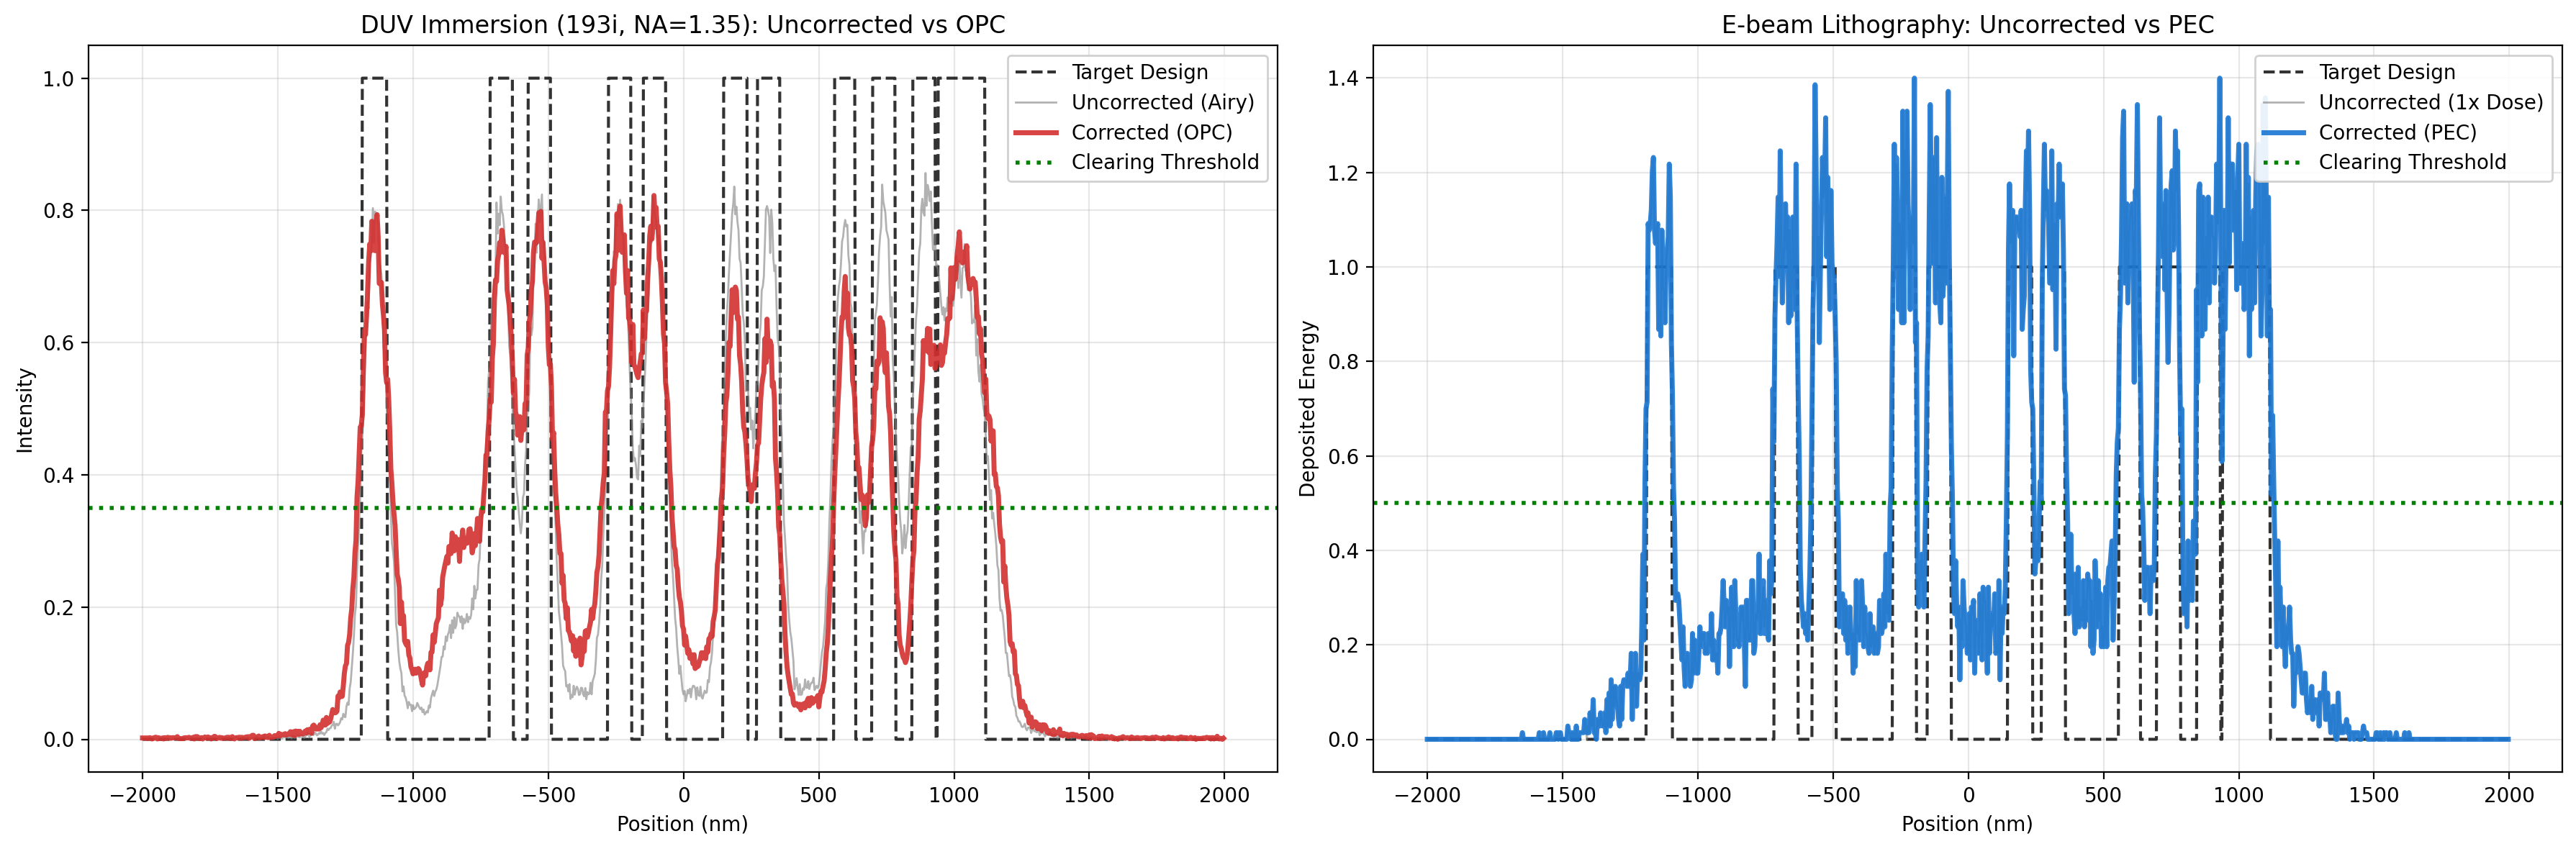

In [ ]:
def plot_full_comparison(
    target: cp.ndarray,
    # Optical Data
    opc_mask: cp.ndarray,
    opt_corr: cp.ndarray,
    opt_unc: cp.ndarray,
    # E-beam Data
    pec_dose: cp.ndarray,
    eb_corr: cp.ndarray,
    eb_unc: cp.ndarray,
    cfg: SimConfig
) -> None:
    """Visualize Target vs Uncorrected vs Corrected with High Contrast (nm units)."""

    # Transfer to CPU
    c_target = cp.asnumpy(target)
    c_opt_corr = cp.asnumpy(opt_corr)
    c_opt_unc = cp.asnumpy(opt_unc)
    c_eb_corr = cp.asnumpy(eb_corr)
    c_eb_unc = cp.asnumpy(eb_unc)

    # Line Cut Indices: Calculate directly in Nanometers
    mid = cfg.grid_n // 2
    x_axis_nm = (np.arange(cfg.grid_n) - mid) * pixel_nm(cfg)

    # --- Plotting ---
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Optical Comparison (DUV Immersion)
    ax[0].set_title(f"DUV Immersion (193i, NA={cfg.opt_na}): Uncorrected vs OPC")

    # Target (Black Dashed)
    ax[0].plot(x_axis_nm, c_target[mid, :], 'k--', linewidth=1.5, alpha=0.8, label="Target Design")

    # Uncorrected (Gray Fill/Line) - Pushes to background
    ax[0].plot(x_axis_nm, c_opt_unc[mid, :], color='gray', linewidth=1, alpha=0.6, label="Uncorrected (Airy)")

    # Corrected (Vibrant Red) - Pops out
    ax[0].plot(x_axis_nm, c_opt_corr[mid, :], color='#D32F2F', linewidth=2.5, alpha=0.9, label="Corrected (OPC)")

    # Threshold (Green)
    ax[0].axhline(cfg.opt_threshold, color='green', linestyle=':', linewidth=2, label="Clearing Threshold")

    ax[0].set_xlabel("Position (nm)")
    ax[0].set_ylabel("Intensity")
    ax[0].legend(loc='upper right', framealpha=0.9)
    ax[0].grid(True, alpha=0.3)

    # 2. E-beam Comparison
    ax[1].set_title("E-beam Lithography: Uncorrected vs PEC")

    # Target (Black Dashed)
    ax[1].plot(x_axis_nm, c_target[mid, :], 'k--', linewidth=1.5, alpha=0.8, label="Target Design")

    # Uncorrected (Gray Fill/Line)
    ax[1].plot(x_axis_nm, c_eb_unc[mid, :], color='gray', linewidth=1, alpha=0.6, label="Uncorrected (1x Dose)")

    # Corrected (Vibrant Blue)
    ax[1].plot(x_axis_nm, c_eb_corr[mid, :], color='#1976D2', linewidth=2.5, alpha=0.9, label="Corrected (PEC)")

    # Threshold (Green)
    ax[1].axhline(cfg.eb_threshold, color='green', linestyle=':', linewidth=2, label="Clearing Threshold")

    ax[1].set_xlabel("Position (nm)")
    ax[1].set_ylabel("Deposited Energy")
    ax[1].legend(loc='upper right', framealpha=0.9)
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the updated plotter
plot_full_comparison(
    target_gpu,
    opc_mask, opc_result, opt_unc_result,
    pec_dose, pec_result, eb_unc_result,
    CFG
)